# CLT Decoder Type Comparison: Full vs LoRA

This notebook pulls training metrics from wandb project `gpt2-clt-lora-comparison` and compares:
- **full**: Standard full decoder weight matrices (baseline)
- **lora**: Low-rank adaptation with shared diagonal base + low-rank cross-layer updates

We compare across LoRA ranks (16, 32, 64, 128) on GPT-2 with expansion_factor=16.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

api = wandb.Api()
project = "gpt2-clt-lora-comparison"

# Fetch all runs from the project
runs = api.runs(project)
print(f"Found {len(runs)} runs:")
for r in runs:
    print(f"  {r.name} (state={r.state}, id={r.id})")

Found 20 runs:
  full (state=finished, id=j3xo4rfh)
  lora_r16 (state=finished, id=jih9a5x9)
  lora_r32 (state=finished, id=vqb8t66v)
  lora_r128 (state=finished, id=q48ka147)
  lora_r64 (state=finished, id=2rtvi4iq)
  full (state=finished, id=nbozk712)
  lora_r16 (state=finished, id=mbn00tfb)
  lora_r32 (state=finished, id=tlx5lgq8)
  lora_r128 (state=finished, id=wsy3r6gi)
  lora_r64 (state=finished, id=fpbvddjz)
  lora_r16 (state=failed, id=44lzaosb)
  lora_r32 (state=failed, id=4j9xbjki)
  full (state=failed, id=ne64qtcn)
  lora_r64 (state=failed, id=msl580ke)
  lora_r128 (state=failed, id=rslphwlu)
  lora_r128 (state=finished, id=8optnhai)
  lora_r16 (state=finished, id=us8p0feb)
  full (state=finished, id=zsxsay5n)
  lora_r64 (state=finished, id=8e90d99g)
  lora_r32 (state=finished, id=n94fz719)


## Parameter Counts & Training Summary

In [2]:
# Load history for each run — pick latest finished run per name
from collections import defaultdict

latest_runs = {}
for run in runs:
    if run.state != "finished":
        continue
    name = run.name
    if name not in latest_runs or run.created_at > latest_runs[name].created_at:
        latest_runs[name] = run

experiments = {}
for name, run in latest_runs.items():
    history = run.history(samples=10000)
    summary = run.summary._json_dict
    config = run.config
    experiments[name] = {
        "history": history,
        "summary": summary,
        "config": config,
    }

# Sort by a canonical order
order = ["full", "lora_r16", "lora_r32", "lora_r64", "lora_r128"]
experiments = {k: experiments[k] for k in order if k in experiments}

print(f"Loaded {len(experiments)} experiments: {list(experiments.keys())}")

# Show summary table
print(f"\n{'Experiment':<15} {'Type':<8} {'Rank':<6}")
print("-" * 30)
for name, data in experiments.items():
    cfg = data["config"]
    dtype = cfg.get("decoder_type", "?")
    rank = cfg.get("decoder_rank", "-")
    if dtype == "full":
        rank = "-"
    print(f"{name:<15} {dtype:<8} {str(rank):<6}")

Loaded 5 experiments: ['full', 'lora_r16', 'lora_r32', 'lora_r64', 'lora_r128']

Experiment      Type     Rank  
------------------------------
full            full     -     
lora_r16        lora     16    
lora_r32        lora     32    
lora_r64        lora     64    
lora_r128       lora     128   


## Training Curves

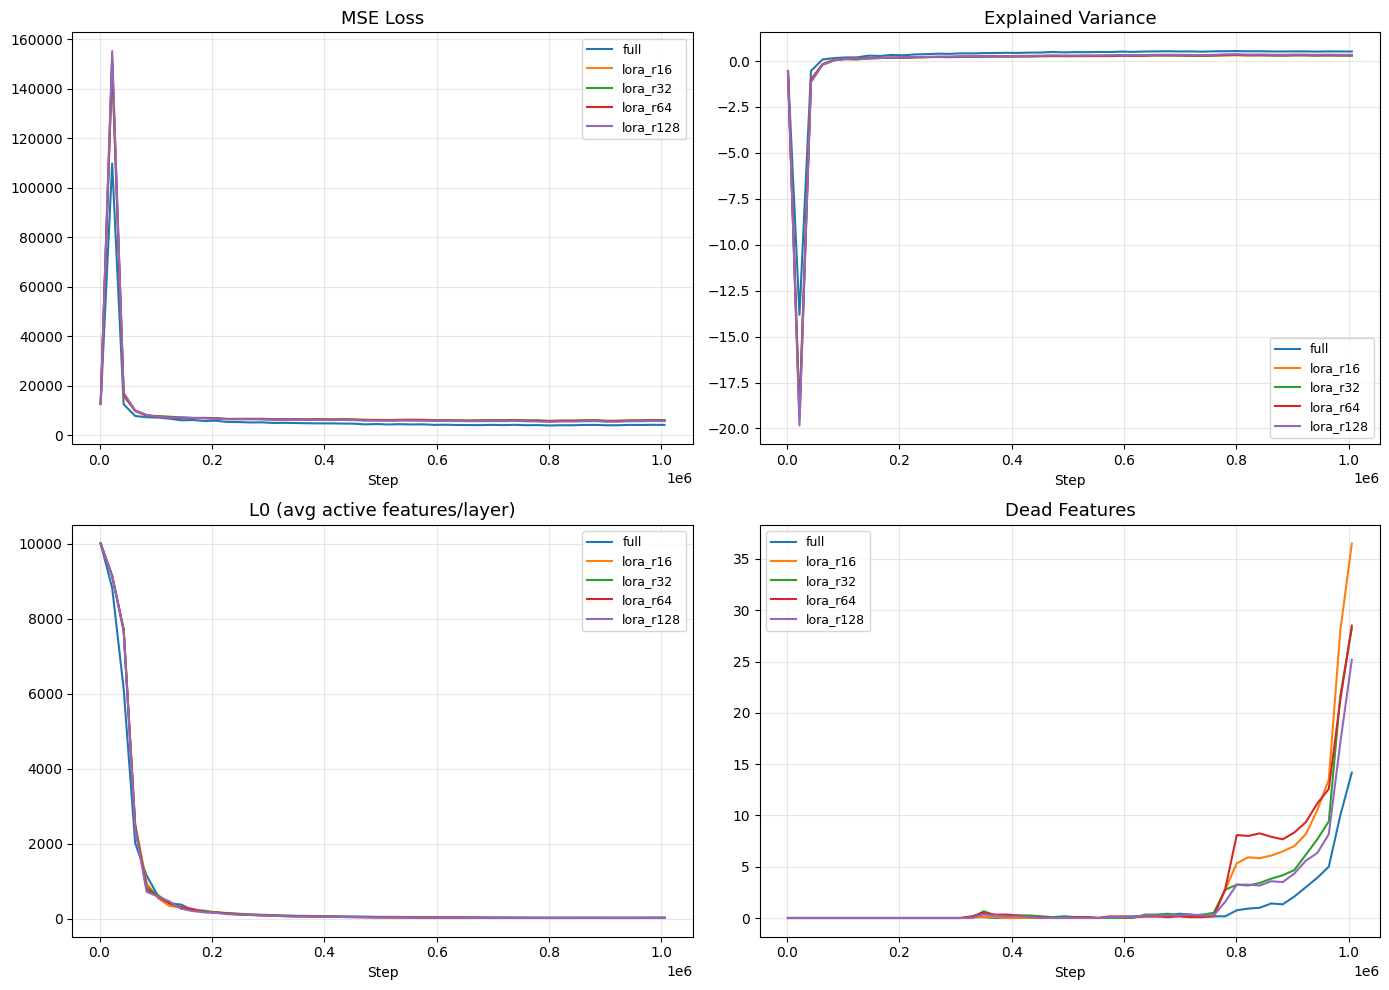

In [3]:
colors = {
    'full': '#1f77b4',
    'lora_r16': '#ff7f0e',
    'lora_r32': '#2ca02c',
    'lora_r64': '#d62728',
    'lora_r128': '#9467bd',
}

save_dir = "/data/group_data/r3lit_rl/clt_experiments/results"
import os
os.makedirs(save_dir, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_keys = [
    ("losses/mse_loss", "MSE Loss"),
    ("metrics/explained_variance", "Explained Variance"),
    ("metrics/l0", "L0 (avg active features/layer)"),
    ("metrics/dead_features", "Dead Features"),
]

for name, data in experiments.items():
    df = data["history"]
    color = colors.get(name, None)

    for idx, (key, title) in enumerate(metric_keys):
        ax = axes[idx // 2, idx % 2]
        if key in df.columns:
            subset = df[["_step", key]].dropna()
            ax.plot(subset["_step"], subset[key], label=name, color=color, linewidth=1.5)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Step")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{save_dir}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Metrics Comparison

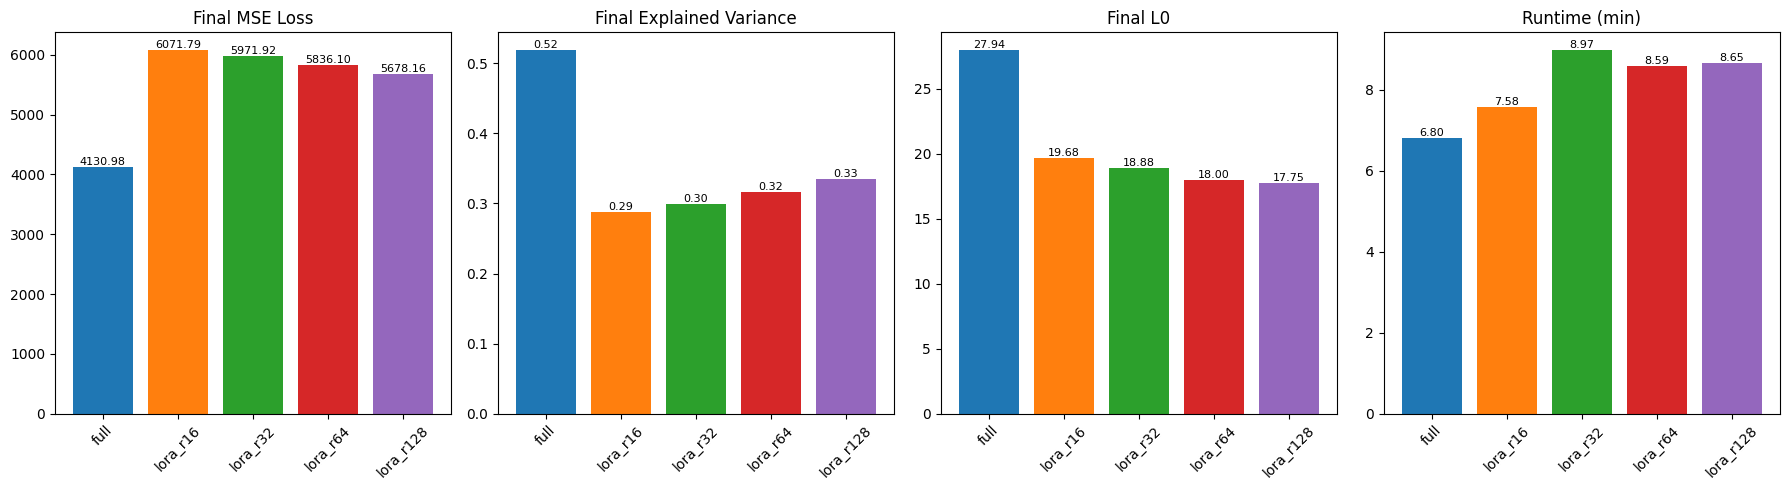

In [4]:
names = list(experiments.keys())
bar_colors = [colors.get(n, 'gray') for n in names]

# Extract final values from wandb summary
final_mse = [experiments[n]["summary"].get("losses/mse_loss", 0) for n in names]
final_ev = [experiments[n]["summary"].get("metrics/explained_variance", 0) for n in names]
final_l0 = [experiments[n]["summary"].get("metrics/l0", 0) for n in names]
runtime = [experiments[n]["summary"].get("_runtime", 0) for n in names]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

charts = [
    (final_mse, "Final MSE Loss"),
    (final_ev, "Final Explained Variance"),
    (final_l0, "Final L0"),
    ([t / 60 for t in runtime], "Runtime (min)"),
]

for ax, (values, title) in zip(axes, charts):
    bars = ax.bar(names, values, color=bar_colors)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{save_dir}/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Efficiency Analysis: Quality vs Parameters

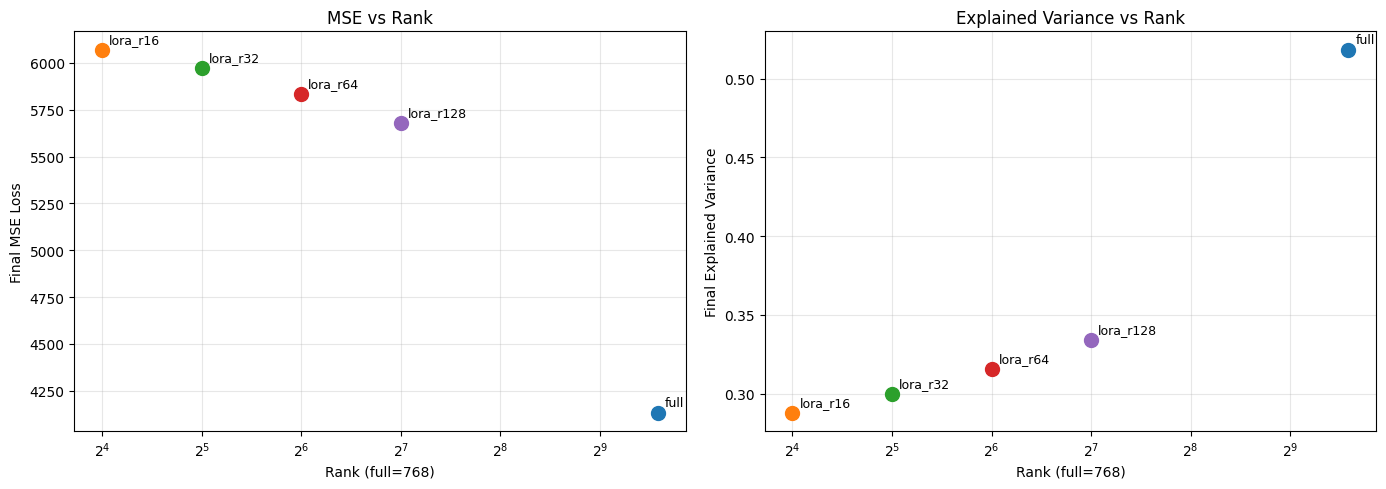

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use decoder_rank as x-axis proxy for param count (full gets special treatment)
for name, data in experiments.items():
    cfg = data["config"]
    summary = data["summary"]
    rank = cfg.get("decoder_rank", 0)
    # Use rank as x-value; full decoder has no rank, use a high value
    x_val = rank if cfg.get("decoder_type") != "full" else 768  # d_in as "effective rank"
    final_mse = summary.get("losses/mse_loss", 0)
    final_ev = summary.get("metrics/explained_variance", 0)
    color = colors.get(name, 'gray')

    axes[0].scatter(x_val, final_mse, color=color, s=100, zorder=5)
    axes[0].annotate(name, (x_val, final_mse), textcoords="offset points",
                     xytext=(5, 5), fontsize=9)

    axes[1].scatter(x_val, final_ev, color=color, s=100, zorder=5)
    axes[1].annotate(name, (x_val, final_ev), textcoords="offset points",
                     xytext=(5, 5), fontsize=9)

axes[0].set_xlabel("Rank (full=768)")
axes[0].set_ylabel("Final MSE Loss")
axes[0].set_title("MSE vs Rank")
axes[0].set_xscale("log", base=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Rank (full=768)")
axes[1].set_ylabel("Final Explained Variance")
axes[1].set_title("Explained Variance vs Rank")
axes[1].set_xscale("log", base=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{save_dir}/efficiency_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Layer Explained Variance (Final Step)

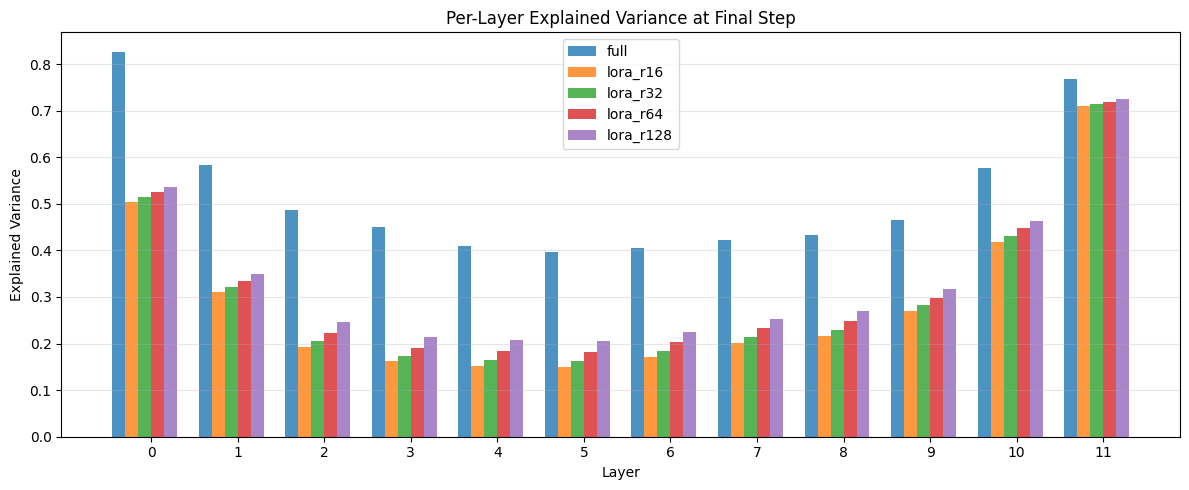

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

n_layers = 12  # GPT-2
x = np.arange(n_layers)
width = 0.15

for i, (name, data) in enumerate(experiments.items()):
    summary = data["summary"]
    ev_per_layer = [summary.get(f"metrics/explained_variance_layer_{l}", 0) for l in range(n_layers)]
    # Try alternate key format if zeros
    if all(v == 0 for v in ev_per_layer):
        ev_per_layer = [summary.get(f"explained_variance/layer_{l}", 0) for l in range(n_layers)]
    color = colors.get(name, 'gray')
    offset = (i - len(experiments) / 2) * width
    ax.bar(x + offset, ev_per_layer, width, label=name, color=color, alpha=0.8)

ax.set_xlabel("Layer")
ax.set_ylabel("Explained Variance")
ax.set_title("Per-Layer Explained Variance at Final Step")
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{save_dir}/per_layer_ev.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

Key findings will be visible from the plots above:
1. **Parameter efficiency**: LoRA reduces decoder parameters significantly vs full
2. **Quality tradeoff**: How much quality (MSE/EV) is lost at each rank
3. **Speed**: Whether LoRA is faster or slower per step (due to on-the-fly weight reconstruction)
4. **Memory**: GPU memory savings from reduced parameter count